In [49]:
import pandas as pd # type: ignore
import numpy as np # type: ignore
import matplotlib.pyplot as plt # type: ignore
import matplotlib.patches as mpatches # type: ignore
import seaborn as sns # type: ignore
from pathlib import Path

In [50]:
# ── CONFIG ────────────────────────────────────────────────────────────────────
# Auto-detects logs folder relative to this notebook's location.
# Works both locally and on the server as long as the notebook is in the repo root.
LOG_DIR = Path(__file__).parent / "logs" if "__file__" in dir() else Path("../logs")
TARGET_LATENCY_S = 1.2   # red dashed line (seconds)
PERCENTILES = [50, 90, 95, 99]
# ─────────────────────────────────────────────────────────────────────────────

In [51]:
def load_latencies(mode: str, v) -> np.ndarray:
    """Read total_latency column from a mode's CSV and return in seconds."""
    path = LOG_DIR / f"{mode}_latency_log.csv"
    if not path.exists():
        print(f"[WARN] {path} not found — skipping {mode}")
        return None
    df = pd.read_csv(path)
    return df["total_latency"].dropna().values / 1000.0 + v

def get_percentiles(latencies: np.ndarray) -> list:
    if latencies is None or len(latencies) == 0:
        return [np.nan] * len(PERCENTILES)
    return [np.percentile(latencies, p) for p in PERCENTILES]

# ── Seaborn theme ─────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams.update({
    "axes.titlesize":  13,
    "axes.labelsize":  12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 10,
    "figure.dpi":      120,
    "axes.titlepad":   10,
})

# Palette: SafeTail = coral, variants = indigo / teal / amber
STYLE = {
    "safetail":  ("#E05C5C", "///"),
    "minload_1": ("#4878CF", "xxx"),
    "minload_2": ("#3BAF8A", "+++"),
    "minload_3": ("#F5A623", "..."),
    "minprop_1": ("#4878CF", "xxx"),
    "minprop_2": ("#3BAF8A", "+++"),
    "minprop_3": ("#F5A623", "..."),
    "rand_1":    ("#4878CF", "xxx"),
    "rand_2":    ("#3BAF8A", "+++"),
    "rand_3":    ("#F5A623", "..."),
}

def plot_panel(ax, group_modes, group_labels, title, ylabel=True, data_dict=None):
    if data_dict is None:
        data_dict = data
    n_groups = len(PERCENTILES)
    n_bars   = len(group_modes)
    bar_w    = 0.16
    x        = np.arange(n_groups)

    for i, (mode, label) in enumerate(zip(group_modes, group_labels)):
        vals         = data_dict[mode]
        color, hatch = STYLE[mode]
        offset       = (i - n_bars / 2 + 0.5) * bar_w
        ax.bar(x + offset, vals, width=bar_w,
               label=label, color=color, hatch=hatch, alpha=0.88,
               edgecolor="white", linewidth=0.6)

    ax.set_xticks(x)
    ax.set_xticklabels([f"{p}th" for p in PERCENTILES])
    ax.set_xlabel("Percentile")
    if ylabel:
        ax.set_ylabel("Total latency (s)")
    ax.set_title(title)
    ax.legend(loc="upper left", framealpha=0.85, edgecolor="#cccccc")
    ax.set_ylim(bottom=0)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#cccccc")
    ax.spines["bottom"].set_color("#cccccc")

In [52]:
# Load all modes
modes = [
    "safetail",
    "minload_1", "minload_2", "minload_3",
    "minprop_1", "minprop_2", "minprop_3",
    "rand_1",    "rand_2",    "rand_3",
]

raw = {mode: load_latencies(mode, v = 0.005) if mode in ["minprop_1", "minprop_2", "minprop_3"] else load_latencies(mode, 0) for mode in modes}

# Truncate all to the minimum number of entries among available CSVs
available = {m: v for m, v in raw.items() if v is not None}
min_count = min(len(v) for v in available.values())
print(f"Entry counts per mode: { {m: len(v) for m, v in available.items()} }")
print(f"Truncating all to {min_count} entries for fair comparison.\n")

truncated = {m: v[:min_count] for m, v in available.items()}

# Compute percentiles
data = {mode: get_percentiles(truncated.get(mode)) for mode in modes}

# Print summary table
labels = [f"{p}%tile" for p in PERCENTILES]
df_summary = pd.DataFrame(
    {m: data[m] for m in modes if not all(np.isnan(data[m]))},
    index=labels
)
print(df_summary.round(4).to_string())

Entry counts per mode: {'safetail': 3690, 'minload_1': 15015, 'minload_2': 15095, 'minload_3': 15035, 'minprop_1': 14723, 'minprop_2': 14843, 'minprop_3': 14991, 'rand_1': 15003, 'rand_2': 15083, 'rand_3': 14865}
Truncating all to 3690 entries for fair comparison.

         safetail  minload_1  minload_2  minload_3  minprop_1  minprop_2  minprop_3  rand_1  rand_2  rand_3
50%tile    0.0301     0.0521     0.0414     0.0320     0.0354     0.0349     0.0349  0.0647  0.0444  0.0365
90%tile    0.0477     0.1207     0.0816     0.0501     0.0529     0.0515     0.0517  0.1238  0.0894  0.0578
95%tile    0.0496     0.1380     0.0993     0.0538     0.0557     0.0537     0.0540  0.1387  0.1032  0.0730
99%tile    0.0530     0.1647     0.1272     0.0799     0.0686     0.0578     0.0589  0.1642  0.1233  0.0995


In [53]:
def plot_comparison(ax, group_modes, group_labels, colors, hatches, title):
    n_groups = len(PERCENTILES)
    n_bars   = len(group_modes)
    bar_w    = 0.15
    x        = np.arange(n_groups)

    for i, (mode, label, color, hatch) in enumerate(zip(group_modes, group_labels, colors, hatches)):
        vals = data[mode]
        offset = (i - n_bars / 2 + 0.5) * bar_w
        ax.bar(x + offset, vals, width=bar_w,
               label=label, color=color, hatch=hatch, alpha=0.88,
               edgecolor="white", linewidth=0.6)

    ax.set_xticks(x)
    ax.set_xticklabels([f"{p}th" for p in PERCENTILES])
    ax.set_xlabel("Percentile")
    ax.set_ylabel("Total latency (s)")
    ax.set_title(title)
    ax.legend(fontsize=9, loc="upper left", framealpha=0.85, edgecolor="#cccccc")
    ax.set_ylim(bottom=0)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#cccccc")
    ax.spines["bottom"].set_color("#cccccc")

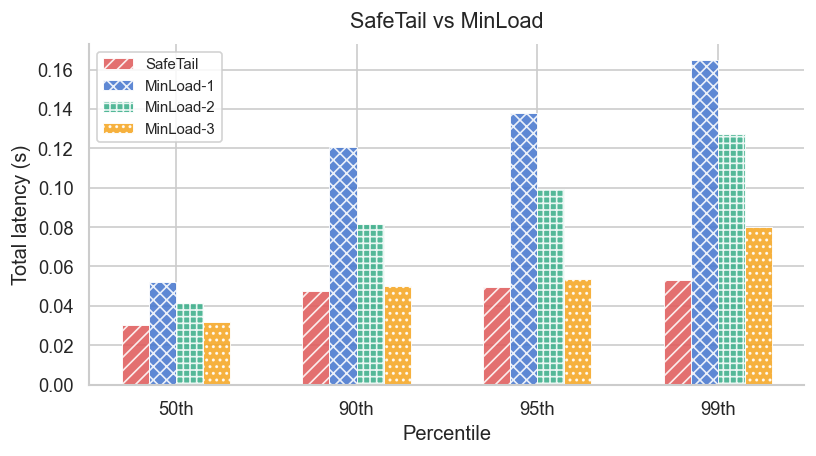

In [54]:
fig, ax = plt.subplots(figsize=(7, 4))
plot_comparison(
    ax,
    group_modes  = ["safetail", "minload_1", "minload_2", "minload_3"],
    group_labels = ["SafeTail", "MinLoad-1", "MinLoad-2", "MinLoad-3"],
    colors       = ["#E05C5C", "#4878CF", "#3BAF8A", "#F5A623"],
    hatches      = ["///", "xxx", "+++", "..."],
    title        = "SafeTail vs MinLoad"
)
plt.tight_layout()
plt.show()

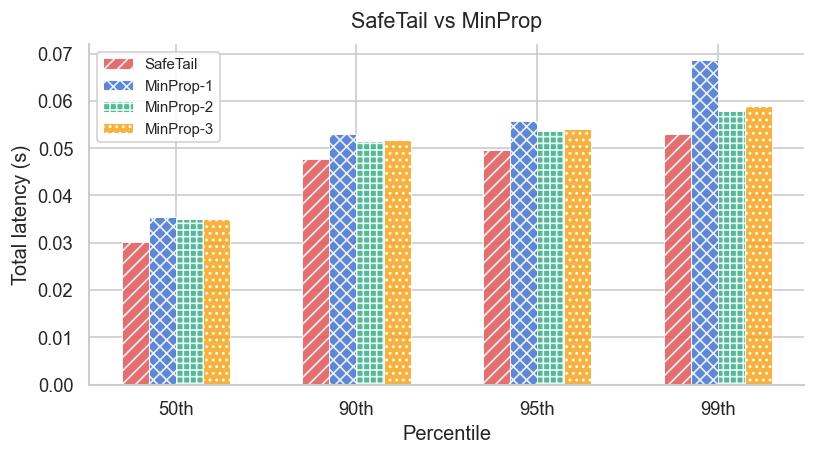

In [55]:
fig, ax = plt.subplots(figsize=(7, 4))
plot_comparison(
    ax,
    group_modes  = ["safetail", "minprop_1", "minprop_2", "minprop_3"],
    group_labels = ["SafeTail", "MinProp-1", "MinProp-2", "MinProp-3"],
    colors       = ["#E05C5C", "#4878CF", "#3BAF8A", "#F5A623"],
    hatches      = ["///", "xxx", "+++", "..."],
    title        = "SafeTail vs MinProp"
)
plt.tight_layout()
plt.show()

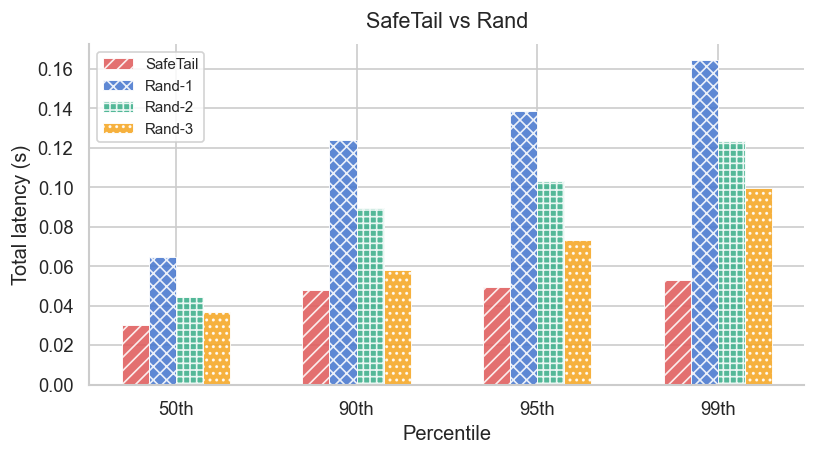

In [56]:
fig, ax = plt.subplots(figsize=(7, 4))
plot_comparison(
    ax,
    group_modes  = ["safetail", "rand_1", "rand_2", "rand_3"],
    group_labels = ["SafeTail", "Rand-1", "Rand-2", "Rand-3"],
    colors       = ["#E05C5C", "#4878CF", "#3BAF8A", "#F5A623"],
    hatches      = ["///", "xxx", "+++", "..."],
    title        = "SafeTail vs Rand"
)
plt.tight_layout()
plt.show()

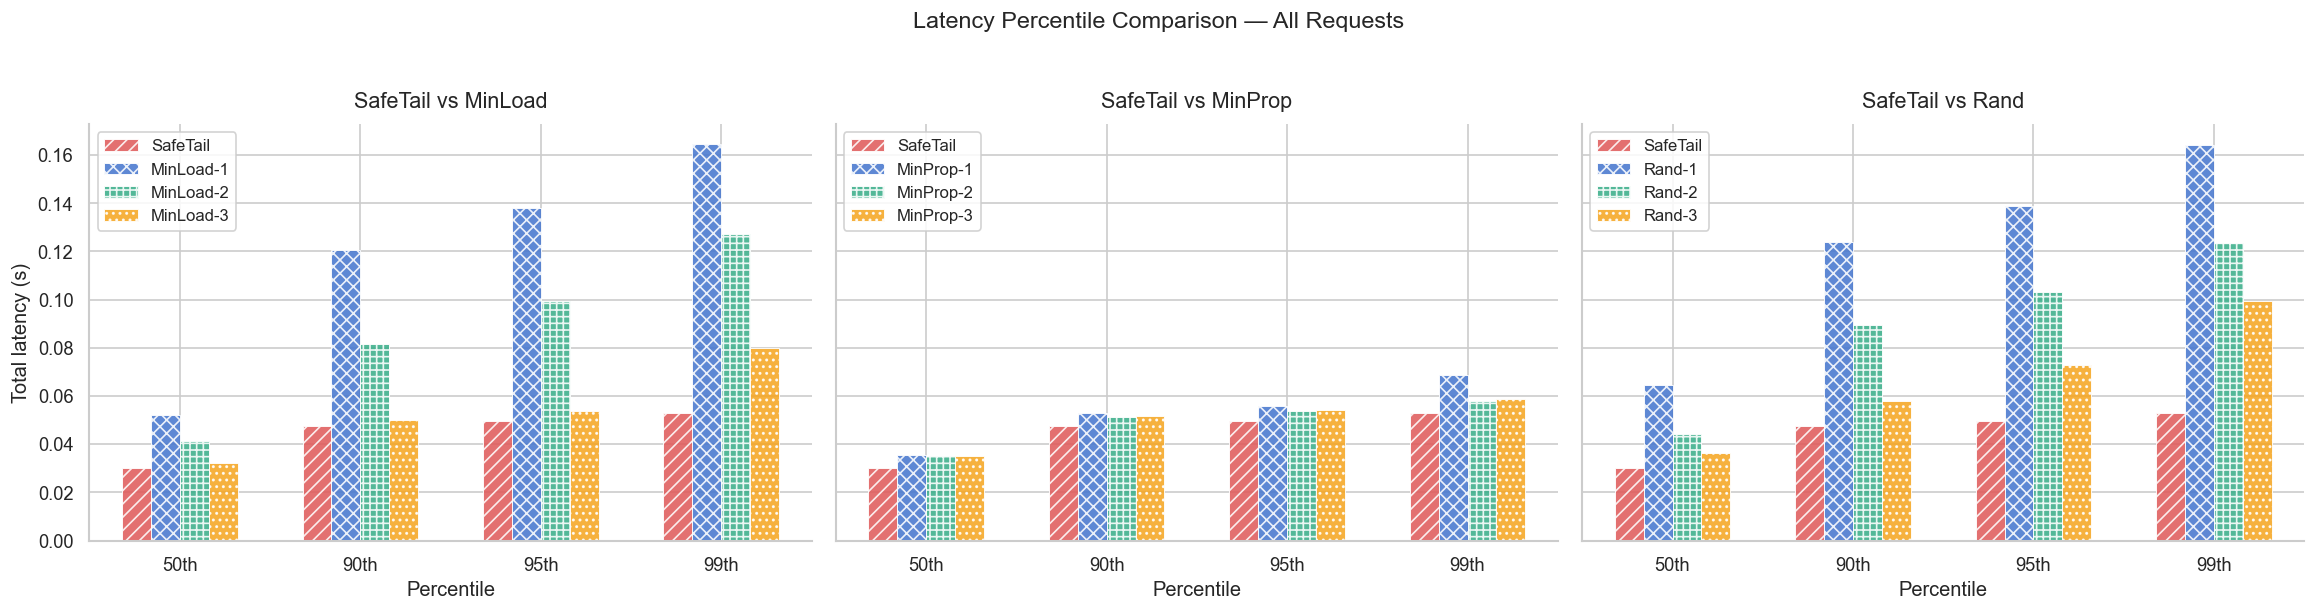

In [57]:
# ── All-requests: 1×3 panel (MinLoad | MinProp | Rand) ───────────────────────
available_modes = [m for m in modes if not all(np.isnan(data[m]))]

panels = []
if any(m in available_modes for m in ["minload_1","minload_2","minload_3"]):
    panels.append(("SafeTail vs MinLoad",
                   ["safetail","minload_1","minload_2","minload_3"],
                   ["SafeTail","MinLoad-1","MinLoad-2","MinLoad-3"]))
if any(m in available_modes for m in ["minprop_1","minprop_2","minprop_3"]):
    panels.append(("SafeTail vs MinProp",
                   ["safetail","minprop_1","minprop_2","minprop_3"],
                   ["SafeTail","MinProp-1","MinProp-2","MinProp-3"]))
if any(m in available_modes for m in ["rand_1","rand_2","rand_3"]):
    panels.append(("SafeTail vs Rand",
                   ["safetail","rand_1","rand_2","rand_3"],
                   ["SafeTail","Rand-1","Rand-2","Rand-3"]))

n_panels = len(panels)
fig, axes = plt.subplots(1, n_panels, figsize=(6.5 * n_panels, 5), sharey=True)
if n_panels == 1:
    axes = [axes]

for idx, (ax, (title, grp_modes, grp_labels)) in enumerate(zip(axes, panels)):
    valid = [(m, l) for m, l in zip(grp_modes, grp_labels) if not all(np.isnan(data[m]))]
    plot_panel(ax, [m for m,_ in valid], [l for _,l in valid], title, ylabel=(idx == 0))

plt.suptitle("Latency Percentile Comparison — All Requests", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


[Segmentation] rows matched per mode: {'safetail': 1233, 'minload_1': 5058, 'minload_2': 5047, 'minload_3': 4962, 'minprop_1': 4835, 'minprop_2': 4959, 'minprop_3': 4887, 'rand_1': 4971, 'rand_2': 5017, 'rand_3': 4909}
  → truncating to 1233 entries

[Predict] rows matched per mode: {'safetail': 1297, 'minload_1': 5023, 'minload_2': 4990, 'minload_3': 5053, 'minprop_1': 5006, 'minprop_2': 4906, 'minprop_3': 5098, 'rand_1': 5063, 'rand_2': 5047, 'rand_3': 4995}
  → truncating to 1297 entries

[Detect] rows matched per mode: {'safetail': 1160, 'minload_1': 4934, 'minload_2': 5058, 'minload_3': 5020, 'minprop_1': 4882, 'minprop_2': 4978, 'minprop_3': 5006, 'rand_1': 4969, 'rand_2': 5019, 'rand_3': 4961}
  → truncating to 1160 entries


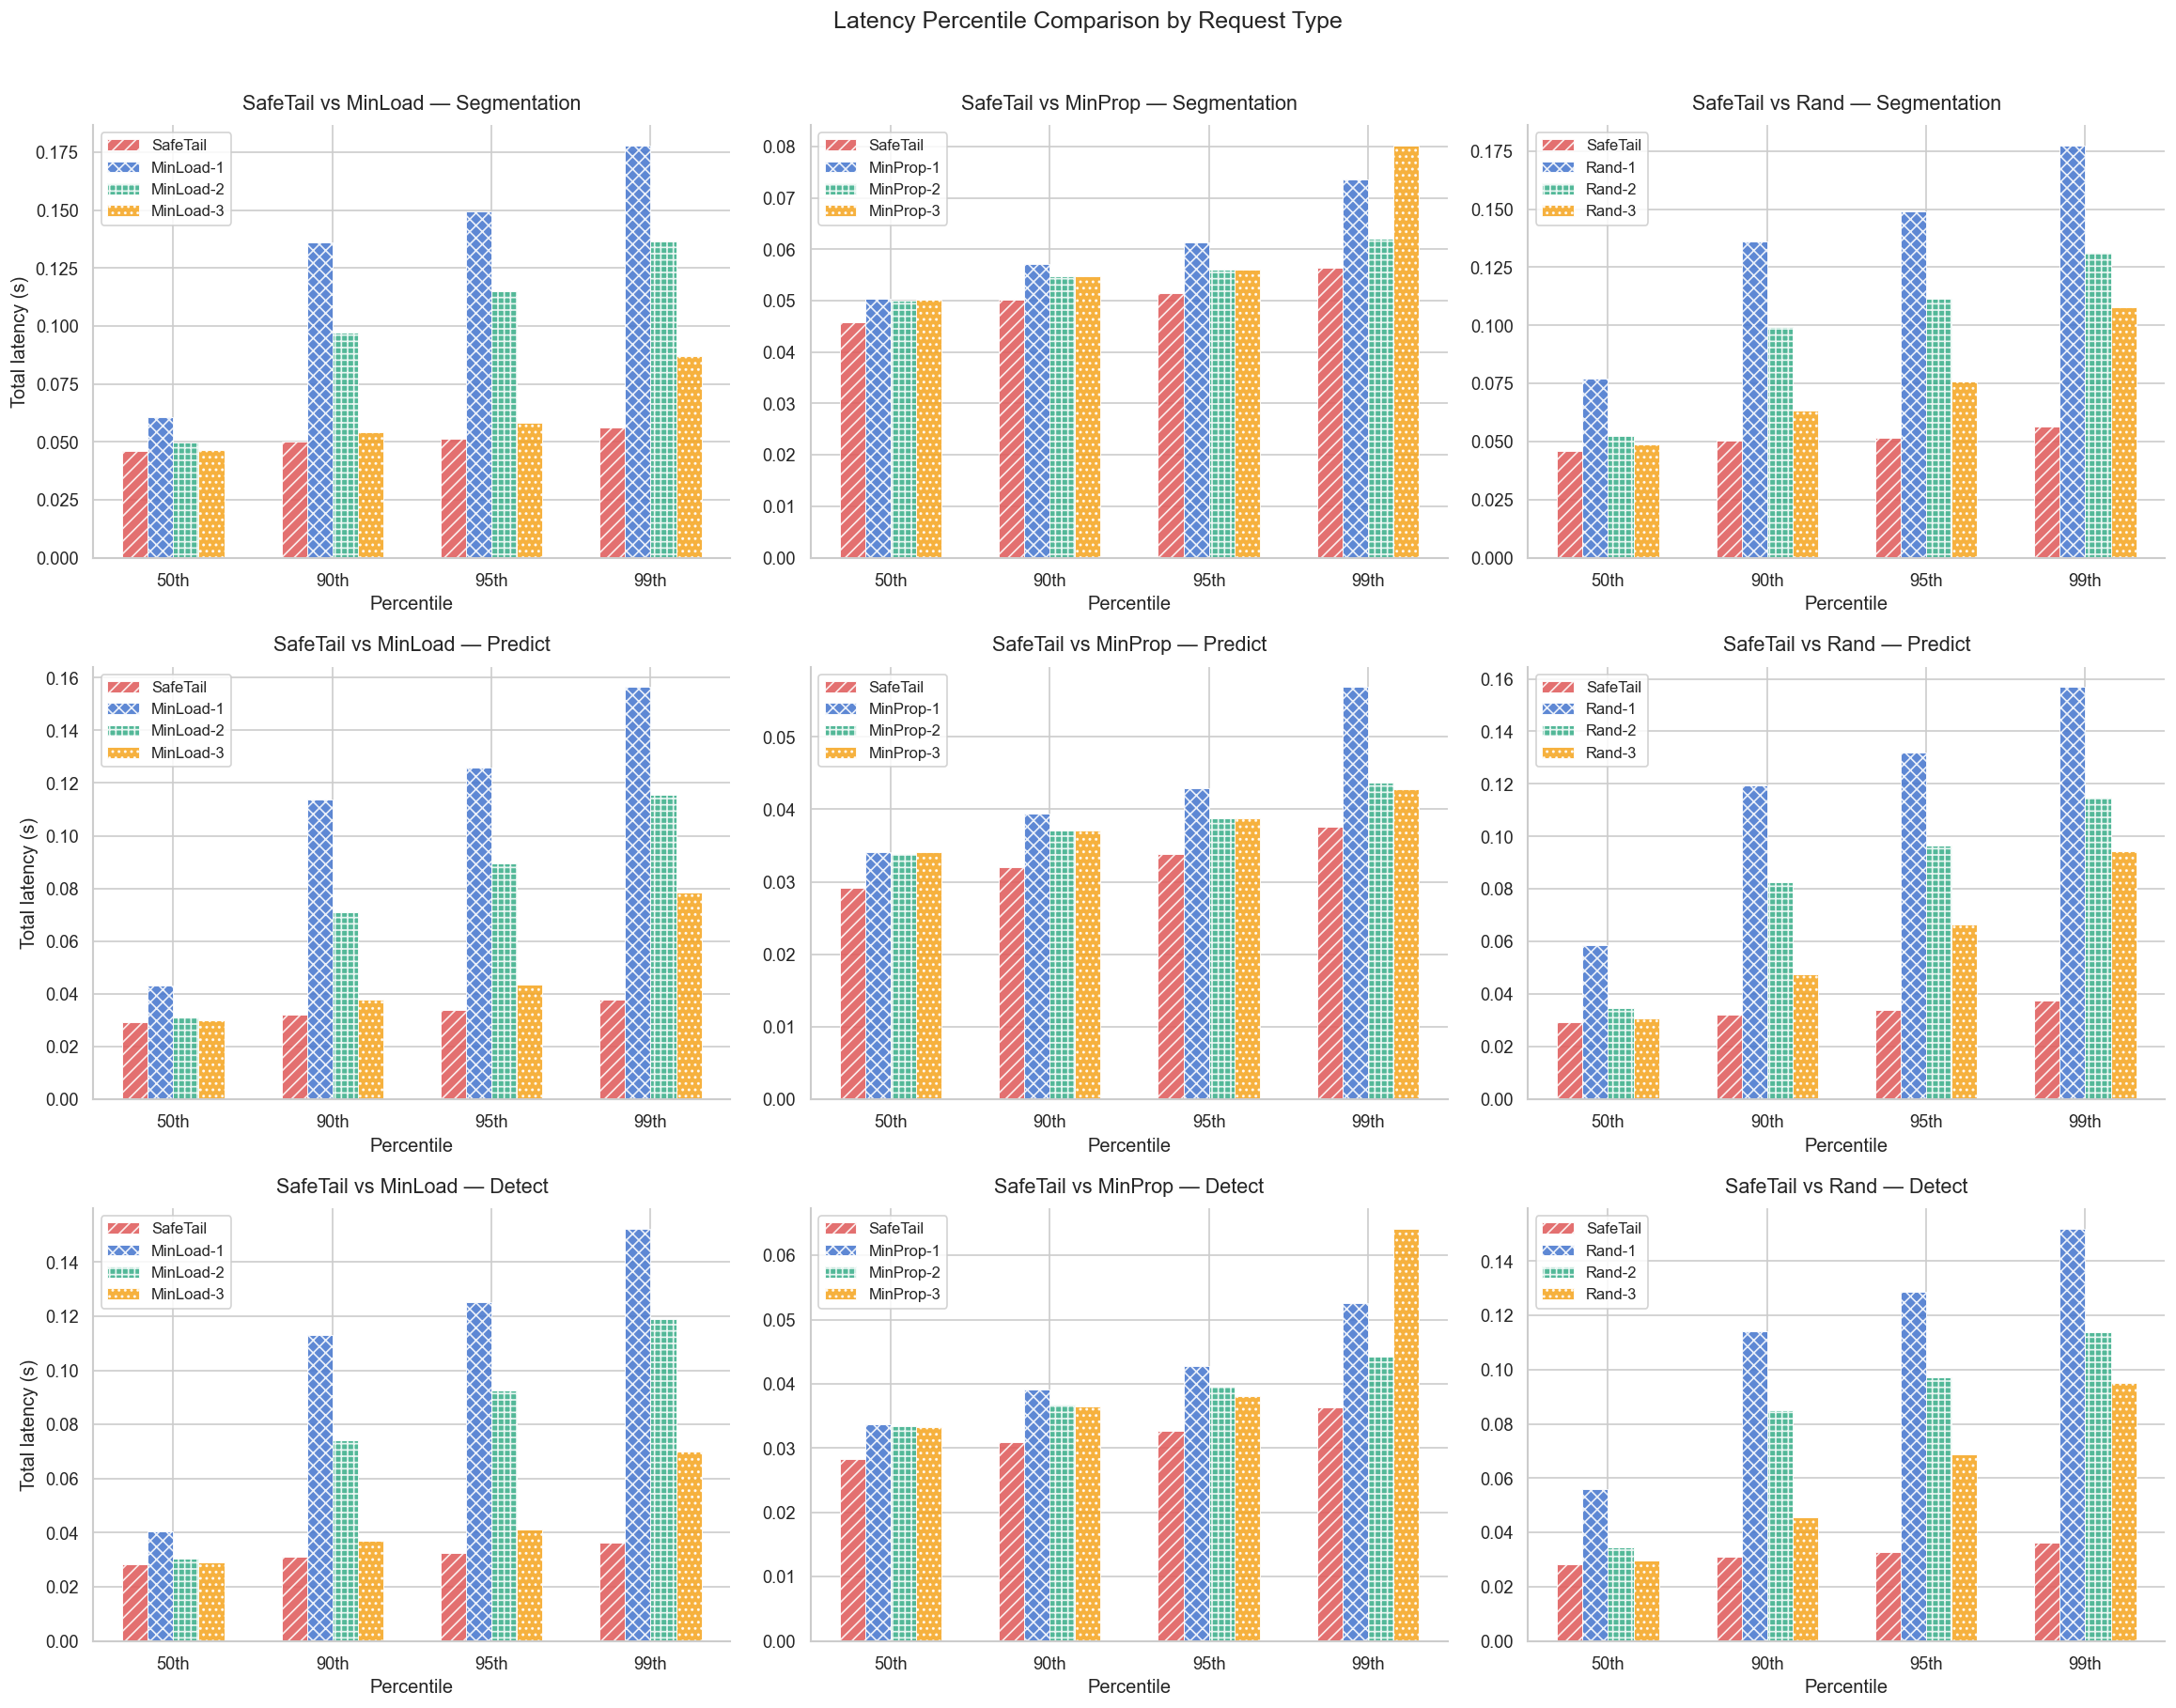

In [58]:
# ── 3×3 grid: rows = request types (s/p/d), cols = baselines ─────────────────

REQ_TYPES = [("s", "Segmentation"), ("p", "Predict"), ("d", "Detect")]
BASELINES = [
    ("MinLoad", ["minload_1", "minload_2", "minload_3"], ["MinLoad-1", "MinLoad-2", "MinLoad-3"]),
    ("MinProp", ["minprop_1", "minprop_2", "minprop_3"], ["MinProp-1", "MinProp-2", "MinProp-3"]),
    ("Rand",    ["rand_1",    "rand_2",    "rand_3"],    ["Rand-1",    "Rand-2",    "Rand-3"]),
]

# Pre-compute filtered dataset for each request-type prefix
filtered_data = {}
for prefix, req_name in REQ_TYPES:
    raw_f = {}
    for mode in modes:
        path = LOG_DIR / f"{mode}_latency_log.csv"
        if not path.exists():
            continue
        df   = pd.read_csv(path)
        mask = df["request_type"].str.startswith(prefix)
        lats = df.loc[mask, "total_latency"].dropna().values / 1000.0
        if mode in ["minprop_1", "minprop_2", "minprop_3"]:
            lats = lats + 0.005
        if len(lats) > 0:
            raw_f[mode] = lats

    print(f"\n[{req_name}] rows matched per mode: { {m: len(v) for m, v in raw_f.items()} }")

    if raw_f:
        min_n = min(len(v) for v in raw_f.values())
        print(f"  → truncating to {min_n} entries")
        trunc = {m: v[:min_n] for m, v in raw_f.items()}
        filtered_data[prefix] = {mode: get_percentiles(trunc.get(mode)) for mode in modes}

# ── Draw the 3×3 figure ──────────────────────────────────────────────────────
n_rows = len(REQ_TYPES)
n_cols = len(BASELINES)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6.5 * n_cols, 5 * n_rows), sharey=False)

for r, (prefix, req_name) in enumerate(REQ_TYPES):
    data_f = filtered_data.get(prefix, {})
    for c, (bl_name, bl_modes, bl_labels) in enumerate(BASELINES):
        ax = axes[r][c]
        if not data_f:
            ax.text(0.5, 0.5, "No dataset", ha="center", va="center", transform=ax.transAxes)
            ax.set_title(f"SafeTail vs {bl_name}\n{req_name}", pad=8)
            ax.axis("off")
            continue
        # safetail + whichever baseline variants have dataset for this request type
        grp_modes  = ["safetail"] + [m for m in bl_modes  if m in data_f and not all(np.isnan(data_f[m]))]
        grp_labels = ["SafeTail"] + [l for m, l in zip(bl_modes, bl_labels) if m in data_f and not all(np.isnan(data_f[m]))]
        if len(grp_modes) == 1:   # only safetail, no baseline dataset
            ax.text(0.5, 0.5, "No baseline dataset", ha="center", va="center", transform=ax.transAxes)
            ax.set_title(f"SafeTail vs {bl_name}\n{req_name}", pad=8)
            ax.axis("off")
            continue
        plot_panel(ax, grp_modes, grp_labels,
                   title=f"SafeTail vs {bl_name} — {req_name}",
                   ylabel=(c == 0),
                   data_dict=data_f)

plt.suptitle("Latency Percentile Comparison by Request Type", fontsize=15, y=1.01)
plt.tight_layout()
plt.show()